<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula04a_Classifica%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

cancer = load_breast_cancer()

df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [2]:
cancer.target_names

array(['malignant', 'benign'], dtype='<U9')

In [3]:
print(f"0: {sum(df['target'] == 0)}")
print(f"1: {sum(df['target'] == 1)}")

0: 212
1: 357


In [4]:
df["target"] = df["target"]*-1 +1
print(f"0: {sum(df['target'] == 0)}")
print(f"1: {sum(df['target'] == 1)}")

0: 357
1: 212


In [5]:
corr = df.corr()['target']
print(corr.sort_values(ascending=False))

target                     1.000000
worst concave points       0.793566
worst perimeter            0.782914
mean concave points        0.776614
worst radius               0.776454
mean perimeter             0.742636
worst area                 0.733825
mean radius                0.730029
mean area                  0.708984
mean concavity             0.696360
worst concavity            0.659610
mean compactness           0.596534
worst compactness          0.590998
radius error               0.567134
perimeter error            0.556141
area error                 0.548236
worst texture              0.456903
worst smoothness           0.421465
worst symmetry             0.416294
mean texture               0.415185
concave points error       0.408042
mean smoothness            0.358560
mean symmetry              0.330499
worst fractal dimension    0.323872
compactness error          0.292999
concavity error            0.253730
fractal dimension error    0.077972
symmetry error            -0

In [6]:
feat1 = corr.sort_values(ascending=False).index[1]
feat2 = corr.sort_values(ascending=False).index[2]
X = df[[feat1, feat2]].to_numpy()
y = df['target'].to_numpy()
print(X.shape)
print(y.shape)

(569, 2)
(569,)


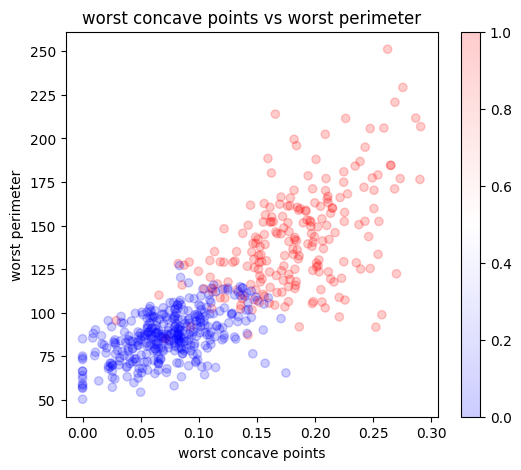

In [7]:
from matplotlib import pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(df[feat1], df[feat2], c=df['target'], cmap='bwr', alpha=0.2)
plt.title(f"{feat1} vs {feat2}")
plt.xlabel(feat1)
plt.ylabel(feat2)
plt.colorbar()
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score
import numpy as np

def include_bias(X):
  return np.c_[np.ones(X.shape[0]), X]

class LinearClassifier(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    X = include_bias(X)
    self.w = np.linalg.pinv(X) @ y
    return self

  def predict(self, X):
    X = include_bias(X)
    return np.array(X @ self.w > 0.5, dtype=int)

model = LinearClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Weights: {model.w}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred)}")

Weights: [-0.64045918  3.47046964  0.00574794]
Test accuracy: 0.9385964912280702


# MaxMin Normalization

In [10]:
print(f"Max: {X.max(axis=0)}")
print(f"Min: {X.min(axis=0)}")

Max: [  0.291 251.2  ]
Min: [ 0.   50.41]


In [11]:
x_train_max = X_train.max(axis=0)
x_train_min = X_train.min(axis=0)

X_train_normalized = (X_train - x_train_min) / (x_train_max - x_train_min)
X_test_normalized = (X_test - x_train_min) / (x_train_max - x_train_min)

print(f"train normalized max: {X_train_normalized.max(axis=0)}")
print(f"train normalized min: {X_train_normalized.min(axis=0)}")
print(f"test normalized max: {X_test_normalized.max(axis=0)}")
print(f"test normalized min: {X_test_normalized.min(axis=0)}")

train normalized max: [1. 1.]
train normalized min: [0. 0.]
test normalized max: [0.98522337 0.81088913]
test normalized min: [ 0.         -0.02074119]


In [12]:
model = LinearClassifier()
model.fit(X_train_normalized, y_train)
y_pred = model.predict(X_test_normalized)
print(f"Weights: {model.w}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred)}")

Weights: [-0.32725418  1.00990666  1.13067636]
Test accuracy: 0.9385964912280702


In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_normalized = scaler.transform(X_train)
X_test_normalized = scaler.transform(X_test)

model = LinearClassifier()
model.fit(X_train_normalized, y_train)
y_pred = model.predict(X_test_normalized)
print(f"Weights: {model.w}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred)}")

Weights: [-0.32725418  1.00990666  1.13067636]
Test accuracy: 0.9385964912280702


# Standardization

In [14]:
x_train_mean = X_train.mean(axis=0)
x_train_std = X_train.std(axis=0)

X_train_standardized = (X_train - x_train_mean) / x_train_std
X_test_standardized = (X_test - x_train_mean) / x_train_std

print(f"train standardized mean: {X_train_standardized.mean(axis=0)}")
print(f"train standardized std: {X_train_standardized.std(axis=0)}")
print(f"test standardized mean: {X_test_standardized.mean(axis=0)}")
print(f"test standardized std: {X_test_standardized.std(axis=0)}")

train standardized mean: [ 1.08338247e-16 -8.64509929e-16]
train standardized std: [1. 1.]
test standardized mean: [0.0324314  0.02366887]
test standardized std: [1.03133991 1.03449335]


In [15]:
model = LinearClassifier()
model.fit(X_train_standardized, y_train)
y_pred = model.predict(X_test_standardized)
print(f"Weights: {model.w}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred)}")

Weights: [0.37142857 0.22646292 0.19162449]
Test accuracy: 0.9385964912280702


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_standardized = scaler.transform(X_train)
X_test_standardized = scaler.transform(X_test)

model = LinearClassifier()
model.fit(X_train_standardized, y_train)
y_pred = model.predict(X_test_standardized)
print(f"Weights: {model.w}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred)}")

Weights: [0.37142857 0.22646292 0.19162449]
Test accuracy: 0.9385964912280702


In [22]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_standardized = scaler.transform(X_train)
X_test_standardized = scaler.transform(X_test)

model = LinearClassifier()
model.fit(X_train_standardized, y_train)
y_pred = model.predict(X_test_standardized)
print(f"Weights: {model.w}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred)}")

Weights: [ 0.62857143  0.69624966 -0.01190919 -0.55334615 -0.11651403  0.00572288
  0.26215375 -0.0798465  -0.18688699  0.0092913  -0.04187303 -0.12226509
  0.00683612  0.01706323  0.05874811 -0.05520225  0.0410383   0.13723145
 -0.11416873  0.00975062  0.00838572 -1.03058888 -0.05826516  0.29043251
  0.54507747 -0.00305242 -0.11809478 -0.1287936   0.08654009 -0.06441487
 -0.02270678]
Test accuracy: 0.956140350877193
